In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats

You measure the position of a star $N$ times with the same telescope i.e. errors are homoscedastic. Let's say the underlying process is Gaussian, the true position is $\mu = 1$ (in suitable units), and the erorrs are $\sigma=0.2$

# MLE applied to a homoscedastic Gaussian

# Part 1

* Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu, \sigma)$. Plot each of the individual likelihoods separately. Also plot their product (i.e. the likelihood of the dataset {$x_i$}). Make sure the x grid has enough points.
* Just read off the maximum likelihood solution (e.g. using np.argsort)
* Compare it with the MLE estimator derived above (expected: $\mu = \frac{1}{N}\Sigma  x_i$ and $\sigma_{\mu}=\frac{\sigma}{\sqrt(N)}$)

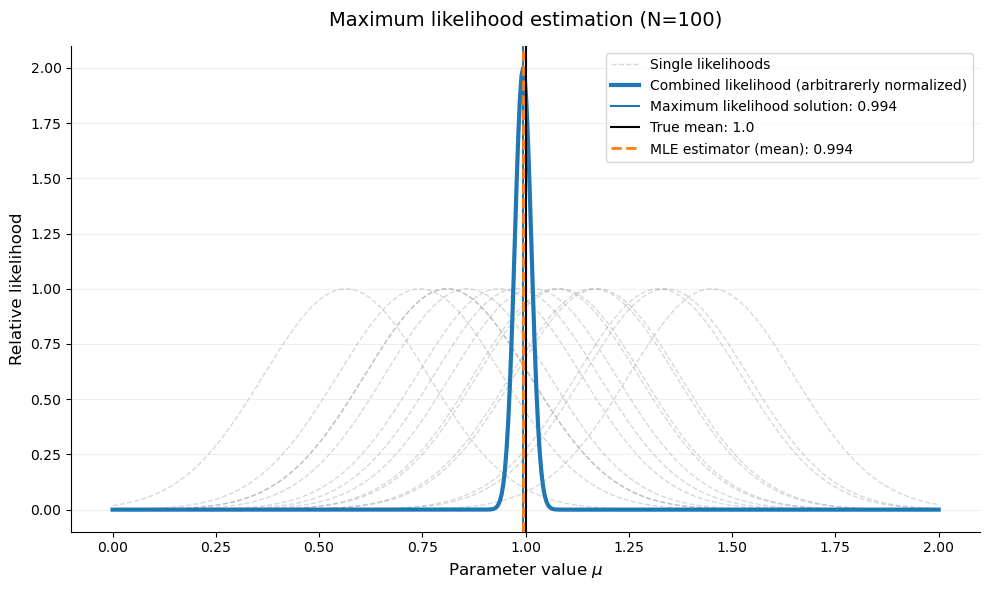

In [3]:
mu_true = 1.0
sigma = 0.2
N = 100
measures = np.random.normal(mu_true, sigma, N)

x = np.linspace(0., 2., 500)
fig, ax = plt.subplots(figsize=(10, 6))

pdfs = norm.pdf(x, loc=measures[:, np.newaxis], scale=sigma) #pdfs has size (N, 500) 

# Total likelihood as product
L_total = np.prod(pdfs, axis=0)
L_total /= np.max(L_total)/2 #Normalization


for i, p in enumerate(pdfs[:15]):
    label = 'Single likelihoods' if i == 0 else None
    ax.plot(x, p/np.max(p), '--', color='gray', alpha=0.3, lw=1, label=label)


ax.plot(x, L_total, color='tab:blue', lw=3, label='Combined likelihood (arbitrarerly normalized)')
max_l = np.argmax(L_total)
plt.axvline(x[max_l], label=f'Maximum likelihood solution: {x[max_l]:.3f}')
mle_est = np.mean(measures)
ax.axvline(mu_true, color='black', linestyle='-', lw=1.5, label=f'True mean: {mu_true}')
ax.axvline(mle_est, color='tab:orange', linestyle='--', lw=2, label=f'MLE estimator (mean): {mle_est:.3f}')


ax.set_title(f'Maximum likelihood estimation (N={N})', fontsize=14, pad=15)
ax.set_xlabel(r'Parameter value $\mu$', fontsize=12)
ax.set_ylabel('Relative likelihood', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

# Part 2

Check the Fisher matrix error estimate makes sense

* do a rough $2^{nd}$ order differentation of our log-likelihood function with np.diff,
* divide through by our $\Delta \theta^2$ to get the correct normalization,
* multiply by -1,
* then take the square root.
* Compare with the Fisher matrix error derived above
* Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees)

In [13]:
rough_fisher = (-np.diff(np.log(L_total+10**(-300)), n=2)[max_l]/(np.diff(x)[0])**2)**(-1/2)
exp_fisher = np.std(measures) /np.sqrt(N)
print(f'Estimated Fisher matrix: {rough_fisher:.3e}')
print(f'MLE estimator: {exp_fisher:.3e}')

Estimated Fisher matrix: 2.000e-02
MLE estimator: 2.108e-02


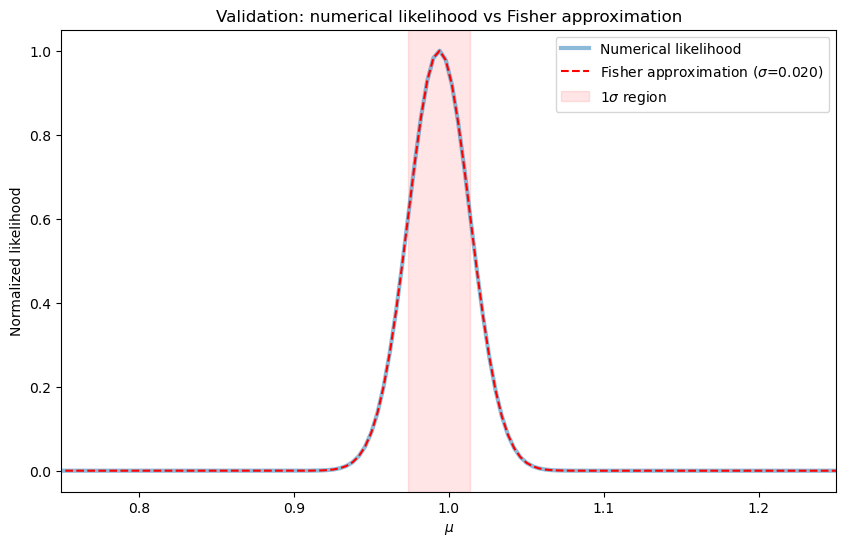

In [18]:
from scipy.stats import norm

fisher_gauss = norm.pdf(x, loc=mle_est, scale=rough_fisher)
fisher_gauss_scaled = fisher_gauss / np.max(fisher_gauss)

plt.figure(figsize=(10, 6))

plt.plot(x, L_total / np.max(L_total), label='Numerical likelihood', lw=3, alpha=0.5)

plt.plot(x, fisher_gauss_scaled, '--', color='red', 
         label=f'Fisher approximation ($\sigma$={rough_fisher:.3f})')


plt.axvspan(mle_est - rough_fisher, mle_est + rough_fisher, 
            color='red', alpha=0.1, label=r'$1\sigma$ region')
plt.xlim(0.75,1.25)
plt.title('Validation: numerical likelihood vs Fisher approximation')
plt.xlabel(r'$\mu$')
plt.ylabel('Normalized likelihood')
plt.legend()
plt.show()

# MLE applied to a heteroscedastic  Gaussian

# Part 3

Let's make our model more realistic. Our N measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). Let's assume that each measurment has a $\sigma_i$ that is normally distributed with mean $0.2$ and standard deviation $0.05$.

Generalize your code from above to this case.

(expected results: $\mu = \frac{\Sigma x_i/\sigma_i^2}{\Sigma 1/\sigma_i^2}$ and $ \sigma _{\mu}=(\Sigma (1/\sigma_i^2))^{-1/2}$)

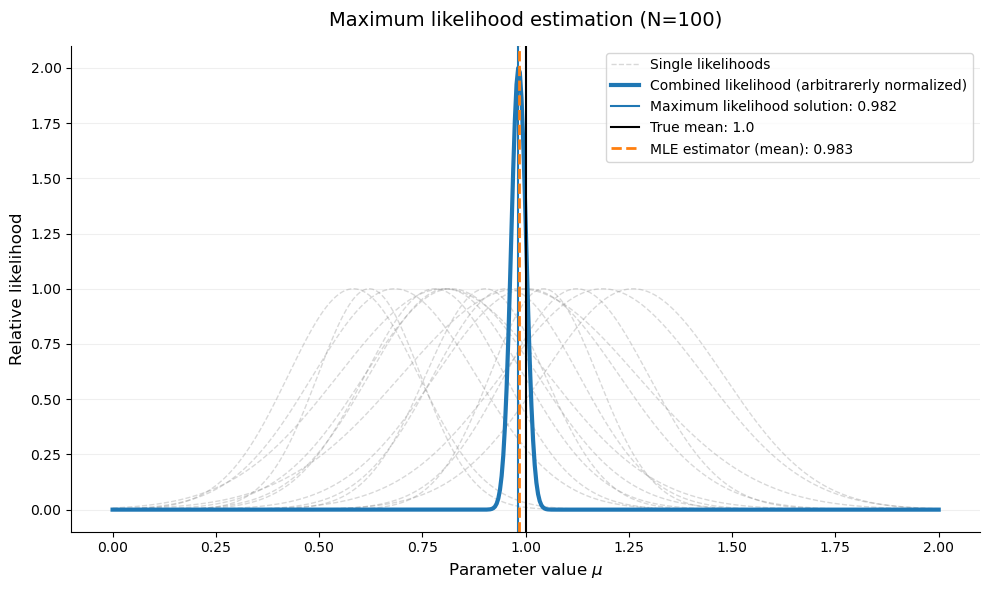

In [20]:
mu_true = 1.0
sigma = 0.2
std_sigma = 0.05
N = 100
measures = np.random.normal(mu_true, sigma, N)
errors = np.random.normal(sigma, std_sigma,N)

x = np.linspace(0., 2., 500)
fig, ax = plt.subplots(figsize=(10, 6))

pdfs = norm.pdf(x, loc=measures[:, np.newaxis], scale=errors[:, np.newaxis]) #pdfs has size (N, 500) 

# Total likelihood as product
L_total = np.prod(pdfs, axis=0)
L_total /= np.max(L_total)/2 #Normalization


for i, p in enumerate(pdfs[:15]):
    label = 'Single likelihoods' if i == 0 else None
    ax.plot(x, p/np.max(p), '--', color='gray', alpha=0.3, lw=1, label=label)


ax.plot(x, L_total, color='tab:blue', lw=3, label='Combined likelihood (arbitrarerly normalized)')
max_l = np.argmax(L_total)
plt.axvline(x[max_l], label=f'Maximum likelihood solution: {x[max_l]:.3f}')
mle_est = np.average(measures, weights=1/errors**2)
ax.axvline(mu_true, color='black', linestyle='-', lw=1.5, label=f'True mean: {mu_true}')
ax.axvline(mle_est, color='tab:orange', linestyle='--', lw=2, label=f'MLE estimator (mean): {mle_est:.3f}')


ax.set_title(f'Maximum likelihood estimation (N={N})', fontsize=14, pad=15)
ax.set_xlabel(r'Parameter value $\mu$', fontsize=12)
ax.set_ylabel('Relative likelihood', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
rough_fisher = (-np.diff(np.log(L_total+10**(-300)), n=2)[max_l]/(np.diff(x)[0])**2)**(-1/2)
exp_fisher = np.cumsum(1/errors**2)[-1]**(-1/2)
print(f'Estimated Fisher matrix: {rough_fisher:.3e}')
print(f'MLE estimator: {exp_fisher:.3e}')

Estimated Fisher matrix: 1.816e-02
MLE estimator: 1.816e-02


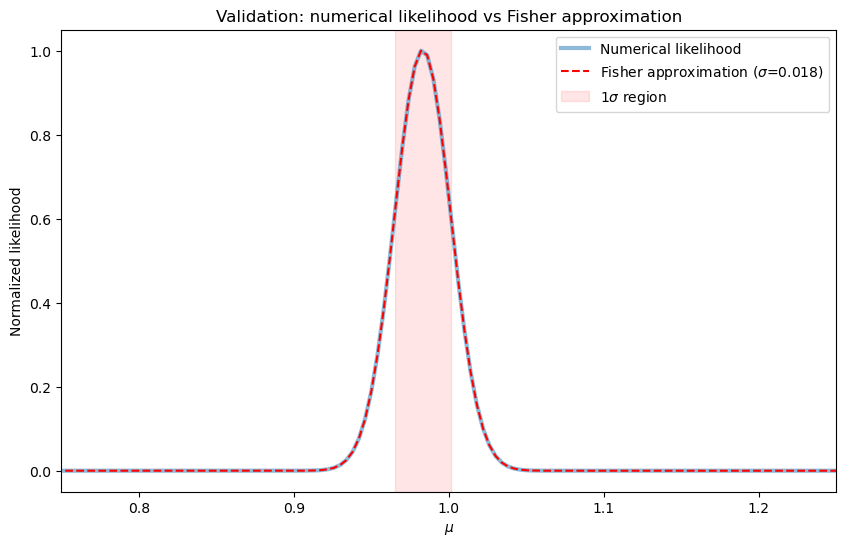

In [25]:
from scipy.stats import norm

fisher_gauss = norm.pdf(x, loc=mle_est, scale=rough_fisher)
fisher_gauss_scaled = fisher_gauss / np.max(fisher_gauss)

plt.figure(figsize=(10, 6))

plt.plot(x, L_total / np.max(L_total), label='Numerical likelihood', lw=3, alpha=0.5)

plt.plot(x, fisher_gauss_scaled, '--', color='red', 
         label=f'Fisher approximation ($\sigma$={rough_fisher:.3f})')


plt.axvspan(mle_est - rough_fisher, mle_est + rough_fisher, 
            color='red', alpha=0.1, label=r'$1\sigma$ region')
plt.xlim(0.75,1.25)
plt.title('Validation: numerical likelihood vs Fisher approximation')
plt.xlabel(r'$\mu$')
plt.ylabel('Normalized likelihood')
plt.legend()
plt.show()